In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [2]:
from google.colab import drive
import zipfile, os

drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/Parkinson's Dataset Final.zip"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

BASE = "/content/dataset/Parkinson's Dataset Final"
print("Dataset extracted to:", BASE)

print("\nBASE folders:")
print(os.listdir(BASE))


Mounted at /content/drive
Dataset extracted to: /content/dataset/Parkinson's Dataset Final

BASE folders:
['Hand Pd', 'New hand pd Dataset']


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight


In [4]:
BASE = "/content/dataset/Parkinson's Dataset Final"

HANDPD_ROOT     = os.path.join(BASE, "Hand Pd")
NEWHANDPD_ROOT  = os.path.join(BASE, "New hand pd Dataset")

print("HANDPD_ROOT:", HANDPD_ROOT)
print("NEWHANDPD_ROOT:", NEWHANDPD_ROOT)

print("\nHandPD folders:", os.listdir(HANDPD_ROOT))
print("NewHandPD folders:", os.listdir(NEWHANDPD_ROOT))


HANDPD_ROOT: /content/dataset/Parkinson's Dataset Final/Hand Pd
NEWHANDPD_ROOT: /content/dataset/Parkinson's Dataset Final/New hand pd Dataset

HandPD folders: ['Meander_HandPD', 'Spiral_HandPD']
NewHandPD folders: ['Healthy', "Parkinson's"]


In [6]:
def preprocess_image(img_path, target_size=(224,224)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    img = cv2.GaussianBlur(img, (3,3), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    img = img.astype(np.float32) / 255.0

    img = np.stack([img, img, img], axis=-1)   # (224,224,3)

    return img


In [7]:
def load_images_recursive(root_folder, label, X, y):
    total = 0

    for root, dirs, files in os.walk(root_folder):
        for f in files:
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                path = os.path.join(root, f)

                img = preprocess_image(path)
                if img is None:
                    continue

                X.append(img)
                y.append(label)
                total += 1

    return total


In [8]:
X, y = [], []

total_handpd = 0

for sub in ["Spiral_HandPD", "Meander_HandPD"]:
    base_sub = os.path.join(HANDPD_ROOT, sub)

    healthy_path = os.path.join(base_sub, "healthy")
    park_path    = os.path.join(base_sub, "parkinson")

    total_handpd += load_images_recursive(healthy_path, 0, X, y)
    total_handpd += load_images_recursive(park_path, 1, X, y)

print("HandPD loaded images:", total_handpd)


HandPD loaded images: 808


In [9]:
total_newhandpd = 0

healthy_root = os.path.join(NEWHANDPD_ROOT, "Healthy")
park_root    = os.path.join(NEWHANDPD_ROOT, "Parkinson's")

total_newhandpd += load_images_recursive(healthy_root, 0, X, y)
total_newhandpd += load_images_recursive(park_root, 1, X, y)

print("NewHandPD loaded images:", total_newhandpd)


NewHandPD loaded images: 512


In [10]:
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("\nFinal X shape:", X.shape)
print("Final y shape:", y.shape)

unique, counts = np.unique(y, return_counts=True)
print("Label counts:", dict(zip(unique, counts)))

print("Healthy:", np.sum(y==0))
print("Parkinson:", np.sum(y==1))



Final X shape: (1320, 224, 224, 3)
Final y shape: (1320,)
Label counts: {np.int32(0): np.int64(449), np.int32(1): np.int64(871)}
Healthy: 449
Parkinson: 871


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("\nTrain label counts:", np.bincount(y_train))
print("Test  label counts:", np.bincount(y_test))

print("Train ratio Parkinson:", np.mean(y_train))
print("Test ratio Parkinson :", np.mean(y_test))



Train label counts: [337 653]
Test  label counts: [112 218]
Train ratio Parkinson: 0.6595959595959596
Test ratio Parkinson : 0.6606060606060606


In [12]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1]),
    y=y_train
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("Class weights:", class_weight_dict)


Class weights: {0: np.float64(1.4688427299703264), 1: np.float64(0.7580398162327718)}


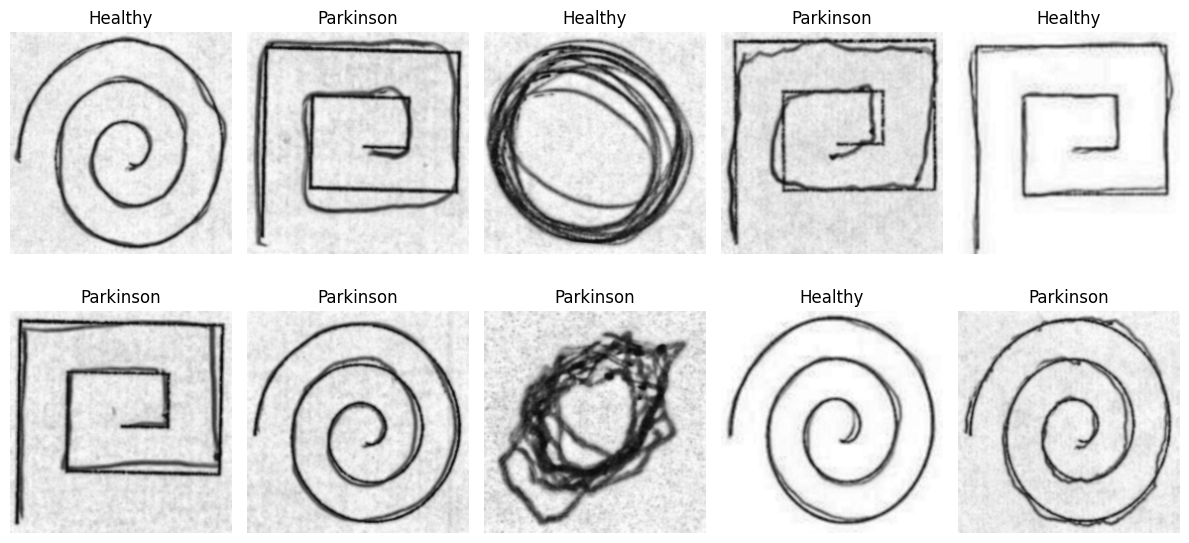

In [13]:
plt.figure(figsize=(12,6))

for i in range(10):
    idx = np.random.randint(0, len(X_train))
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[idx])
    plt.title("Parkinson" if y_train[idx]==1 else "Healthy")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [14]:
import os, shutil
import cv2
import numpy as np
from tqdm import tqdm

REMOVED_DIR = "/content/removed_confusing"
os.makedirs(REMOVED_DIR, exist_ok=True)

def quality_metrics(img_gray):
    """
    img_gray: uint8 grayscale image (224x224)
    returns: dict of metrics
    """
    mean_val = img_gray.mean()
    std_val  = img_gray.std()

    blur_score = cv2.Laplacian(img_gray, cv2.CV_64F).var()

    edges = cv2.Canny(img_gray, 50, 150)
    edge_density = edges.mean() / 255.0

    return {
        "mean": mean_val,
        "std": std_val,
        "blur": blur_score,
        "edge_density": edge_density
    }


TH_MEAN_LOW  = 40
TH_MEAN_HIGH = 220
TH_STD_LOW   = 18
TH_BLUR_LOW  = 35
TH_EDGE_LOW  = 0.01

def is_bad_image(metrics):
    if metrics["mean"] < TH_MEAN_LOW:
        return True
    if metrics["mean"] > TH_MEAN_HIGH:
        return True
    if metrics["std"] < TH_STD_LOW:
        return True
    if metrics["blur"] < TH_BLUR_LOW:
        return True
    if metrics["edge_density"] < TH_EDGE_LOW:
        return True
    return False



bad_paths = []
good_paths = []
good_labels = []

for p, lab in tqdm(list(zip(image_paths, labels)), total=len(image_paths)):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        bad_paths.append(p)
        continue

    img = cv2.resize(img, (224, 224))
    m = quality_metrics(img)

    if is_bad_image(m):
        bad_paths.append(p)
    else:
        good_paths.append(p)
        good_labels.append(lab)

print(" Total images:", len(image_paths))
print(" Bad images detected:", len(bad_paths))
print(" Good images kept:", len(good_paths))

moved = 0
for bp in bad_paths:
    try:
        fname = os.path.basename(bp)
        dest = os.path.join(REMOVED_DIR, fname)

        # if same filename exists, rename
        if os.path.exists(dest):
            base, ext = os.path.splitext(fname)
            dest = os.path.join(REMOVED_DIR, f"{base}_{moved}{ext}")

        shutil.move(bp, dest)
        moved += 1
    except:
        pass

print(" Moved bad images to:", REMOVED_DIR)
print("Moved:", moved)


image_paths_clean = good_paths
labels_clean = np.array(good_labels)

print("\nFinal Clean Dataset:")
print("Images:", len(image_paths_clean))
print("Healthy:", np.sum(labels_clean==0))
print("Parkinson:", np.sum(labels_clean==1))


NameError: name 'image_paths' is not defined

In [17]:
import numpy as np
from tqdm import tqdm

def handpd_filter_auto(img_gray):
    img_gray = img_gray.squeeze()

    # Detect scale
    max_val = img_gray.max()

    # If normalized (0-1), convert to 0-255
    if max_val <= 1.5:
        img_gray = (img_gray * 255.0).astype(np.uint8)
    else:
        img_gray = img_gray.astype(np.uint8)

    mean_val = img_gray.mean()
    std_val  = img_gray.std()

    # Ink pixels: darker than 200 (works for pencil sketches)
    ink_pixels = np.sum(img_gray < 200)
    ink_ratio = ink_pixels / img_gray.size

    # Very loose rules (only remove garbage)
    if mean_val > 252:   # almost blank
        return False
    if mean_val < 5:     # fully black
        return False
    if std_val < 2:      # almost flat
        return False
    if ink_ratio < 0.0005:  # no strokes
        return False

    return True


X_clean = []
y_clean = []
bad_count = 0

for img, lab in tqdm(list(zip(X, y)), total=len(X)):
    if handpd_filter_auto(img):
        X_clean.append(img)
        y_clean.append(lab)
    else:
        bad_count += 1

X_clean = np.array(X_clean)
y_clean = np.array(y_clean)

print("Total images:", len(X))
print("Removed bad images:", bad_count)
print("Final clean images:", len(X_clean))
print("Healthy:", np.sum(y_clean==0))
print("Parkinson:", np.sum(y_clean==1))


100%|██████████| 1320/1320 [00:01<00:00, 1155.43it/s]


Total images: 1320
Removed bad images: 0
Final clean images: 1320
Healthy: 449
Parkinson: 871


In [18]:
!pip -q install imagehash

import os
import cv2
import numpy as np
from PIL import Image
import imagehash
from tqdm import tqdm
from collections import defaultdict


BASE = "/content/dataset/Parkinson's Dataset Final"
NEW_HANDPD_ROOT = os.path.join(BASE, "New hand pd Dataset")

HEALTHY_ROOT = os.path.join(NEW_HANDPD_ROOT, "Healthy")
PARK_ROOT    = os.path.join(NEW_HANDPD_ROOT, "Parkinson's")

print("Healthy Root:", HEALTHY_ROOT)
print("Parkinson Root:", PARK_ROOT)


image_paths = []
labels = []

def collect_images(root, label):
    for sub in os.listdir(root):
        sub_path = os.path.join(root, sub)
        if not os.path.isdir(sub_path):
            continue

        for root2, dirs2, files2 in os.walk(sub_path):
            for f in files2:
                if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                    image_paths.append(os.path.join(root2, f))
                    labels.append(label)

collect_images(HEALTHY_ROOT, 0)
collect_images(PARK_ROOT, 1)

print("\nTotal collected images:", len(image_paths))
print("Healthy:", labels.count(0))
print("Parkinson:", labels.count(1))

def get_phash(img_path):
    try:
        img = Image.open(img_path).convert("L")
        img = img.resize((224, 224))
        return imagehash.phash(img)
    except:
        return None


PHASH_DISTANCE_THRESHOLD = 4

hash_to_paths = defaultdict(list)

print("\nComputing pHash for all images...")
for p in tqdm(image_paths):
    h = get_phash(p)
    if h is not None:
        hash_to_paths[str(h)].append(p)

print("\nUnique hashes:", len(hash_to_paths))


keep_paths = []
remove_paths = []

for h, paths in hash_to_paths.items():

    keep_paths.append(paths[0])
    if len(paths) > 1:
        remove_paths.extend(paths[1:])

print("\nExact duplicates removed:", len(remove_paths))
print("Remaining after exact duplicate removal:", len(keep_paths))

final_keep = []
used = set()

hash_list = list(hash_to_paths.keys())

print("\nRemoving near-duplicates (this may take 1-2 minutes)...")

for i in tqdm(range(len(hash_list))):
    if hash_list[i] in used:
        continue

    base_hash = imagehash.hex_to_hash(hash_list[i])
    used.add(hash_list[i])


    final_keep.append(hash_to_paths[hash_list[i]][0])

    for j in range(i+1, len(hash_list)):
        if hash_list[j] in used:
            continue
        compare_hash = imagehash.hex_to_hash(hash_list[j])

        if base_hash - compare_hash <= PHASH_DISTANCE_THRESHOLD:
            # mark this hash as duplicate group
            used.add(hash_list[j])

print("\nFinal kept images:", len(final_keep))

clean_paths = []
clean_labels = []

path_to_label = dict(zip(image_paths, labels))

for p in final_keep:
    if p in path_to_label:
        clean_paths.append(p)
        clean_labels.append(path_to_label[p])

print("\n===== CLEAN DATASET SUMMARY =====")
print("Final clean images:", len(clean_paths))
print("Healthy:", clean_labels.count(0))
print("Parkinson:", clean_labels.count(1))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 14.0 MB/s eta 0:00:00
Healthy Root: /content/dataset/Parkinson's Dataset Final/New hand pd Dataset/Healthy
Parkinson Root: /content/dataset/Parkinson's Dataset Final/New hand pd Dataset/Parkinson's

Total collected images: 512
Healthy: 233
Parkinson: 279

Computing pHash for all images...


100%|██████████| 512/512 [00:05<00:00, 101.96it/s]



Unique hashes: 467

Exact duplicates removed: 45
Remaining after exact duplicate removal: 467

Removing near-duplicates (this may take 1-2 minutes)...


100%|██████████| 467/467 [00:02<00:00, 200.08it/s]


Final kept images: 359

===== CLEAN DATASET SUMMARY =====
Final clean images: 359
Healthy: 185
Parkinson: 174


In [21]:
IMG_SIZE = 224

X = []
y = []

for p, lab in tqdm(list(zip(clean_paths, clean_labels))):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)

    X.append(img)
    y.append(lab)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("\nFinal X shape:", X.shape)
print("Healthy:", np.sum(y==0))
print("Parkinson:", np.sum(y==1))


100%|██████████| 359/359 [00:01<00:00, 278.45it/s]



Final X shape: (359, 224, 224, 1)
Healthy: 185
Parkinson: 174


In [19]:
!pip -q install imagehash

import os
import cv2
import numpy as np
from PIL import Image
import imagehash
from tqdm import tqdm
from collections import defaultdict


BASE = "/content/dataset/Parkinson's Dataset Final"
HANDPD_ROOT = os.path.join(BASE, "Hand Pd")

SPIRAL_ROOT  = os.path.join(HANDPD_ROOT, "Spiral_HandPD")
MEANDER_ROOT = os.path.join(HANDPD_ROOT, "Meander_HandPD")

print("Spiral Root :", SPIRAL_ROOT)
print("Meander Root:", MEANDER_ROOT)


image_paths = []
labels = []

def collect_images_handpd(base_root):

    for cls in os.listdir(base_root):
        cls_path = os.path.join(base_root, cls)
        if not os.path.isdir(cls_path):
            continue

        cls_lower = cls.lower()

        if cls_lower == "healthy":
            lab = 0
        elif cls_lower == "parkinson":
            lab = 1
        else:
            continue

        for root2, dirs2, files2 in os.walk(cls_path):
            for f in files2:
                if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                    image_paths.append(os.path.join(root2, f))
                    labels.append(lab)

collect_images_handpd(SPIRAL_ROOT)
collect_images_handpd(MEANDER_ROOT)

print("\nTotal collected images:", len(image_paths))
print("Healthy:", labels.count(0))
print("Parkinson:", labels.count(1))

def get_phash(img_path):
    try:
        img = Image.open(img_path).convert("L")
        img = img.resize((224, 224))
        return imagehash.phash(img)
    except:
        return None


PHASH_DISTANCE_THRESHOLD = 4

hash_to_paths = defaultdict(list)

print("\nComputing pHash for all HandPD images...")
for p in tqdm(image_paths):
    h = get_phash(p)
    if h is not None:
        hash_to_paths[str(h)].append(p)

print("\nUnique hashes:", len(hash_to_paths))

keep_paths = []
remove_paths = []

for h, paths in hash_to_paths.items():
    keep_paths.append(paths[0])
    if len(paths) > 1:
        remove_paths.extend(paths[1:])

print("\nExact duplicates removed:", len(remove_paths))
print("Remaining after exact duplicates:", len(keep_paths))


final_keep = []
used = set()

hash_list = list(hash_to_paths.keys())

print("\nRemoving near-duplicates...")
for i in tqdm(range(len(hash_list))):
    if hash_list[i] in used:
        continue

    base_hash = imagehash.hex_to_hash(hash_list[i])
    used.add(hash_list[i])

    final_keep.append(hash_to_paths[hash_list[i]][0])

    for j in range(i+1, len(hash_list)):
        if hash_list[j] in used:
            continue
        compare_hash = imagehash.hex_to_hash(hash_list[j])

        if base_hash - compare_hash <= PHASH_DISTANCE_THRESHOLD:
            used.add(hash_list[j])

print("\nFinal kept HandPD images:", len(final_keep))


clean_paths_handpd = []
clean_labels_handpd = []

path_to_label = dict(zip(image_paths, labels))

for p in final_keep:
    if p in path_to_label:
        clean_paths_handpd.append(p)
        clean_labels_handpd.append(path_to_label[p])

print("\n HANDPD CLEAN SUMMARY ")
print("Final clean HandPD images:", len(clean_paths_handpd))
print("Healthy:", clean_labels_handpd.count(0))
print("Parkinson:", clean_labels_handpd.count(1))


Spiral Root : /content/dataset/Parkinson's Dataset Final/Hand Pd/Spiral_HandPD
Meander Root: /content/dataset/Parkinson's Dataset Final/Hand Pd/Meander_HandPD

Total collected images: 808
Healthy: 216
Parkinson: 592

Computing pHash for all HandPD images...


100%|██████████| 808/808 [00:07<00:00, 114.88it/s]



Unique hashes: 735

Exact duplicates removed: 73
Remaining after exact duplicates: 735

Removing near-duplicates...


100%|██████████| 735/735 [00:06<00:00, 105.41it/s]


Final kept HandPD images: 557

 HANDPD CLEAN SUMMARY 
Final clean HandPD images: 557
Healthy: 119
Parkinson: 438


In [20]:
IMG_SIZE = 224

X_handpd = []
y_handpd = []

for p, lab in tqdm(list(zip(clean_paths_handpd, clean_labels_handpd))):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)

    X_handpd.append(img)
    y_handpd.append(lab)

X_handpd = np.array(X_handpd, dtype=np.float32)
y_handpd = np.array(y_handpd, dtype=np.int32)

print("\nX_handpd shape:", X_handpd.shape)
print("Healthy:", np.sum(y_handpd==0))
print("Parkinson:", np.sum(y_handpd==1))


100%|██████████| 557/557 [00:02<00:00, 194.28it/s]



X_handpd shape: (557, 224, 224, 1)
Healthy: 119
Parkinson: 438


In [28]:

try:
    print("HandPD CLEAN found ")
    print("Clean HandPD:", len(clean_paths_handpd))
except:
    print("HandPD CLEAN not found -> using raw images instead")
    clean_paths_handpd  = image_paths_handpd
    clean_labels_handpd = labels_handpd

print("Final HandPD used:", len(clean_paths_handpd))


HandPD CLEAN found 
Clean HandPD: 557
Final HandPD used: 557


In [33]:
print("\n===== CLEAN NEWHANDPD SUMMARY =====")
print("Total clean NewHandPD images:", len(clean_paths))
print("Healthy:", clean_labels.count(0))
print("Parkinson:", clean_labels.count(1))



===== CLEAN NEWHANDPD SUMMARY =====
Total clean NewHandPD images: 359
Healthy: 185
Parkinson: 174


In [34]:
# Merge both clean datasets

merged_paths = clean_paths_handpd + clean_paths
merged_labels = clean_labels_handpd + clean_labels

print("\n MERGED CLEAN DATASET SUMMARY ")
print("Total merged images:", len(merged_paths))
print("Healthy:", merged_labels.count(0))
print("Parkinson:", merged_labels.count(1))



 MERGED CLEAN DATASET SUMMARY 
Total merged images: 916
Healthy: 304
Parkinson: 612


In [35]:
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter

merged_paths = np.array(merged_paths)
merged_labels = np.array(merged_labels)

print("Before split:", Counter(merged_labels))

train_paths, test_paths, y_train, y_test = train_test_split(
    merged_paths,
    merged_labels,
    test_size=0.25,
    random_state=42,
    stratify=merged_labels
)

print("\n SPLIT SUMMARY ")
print("Train:", len(train_paths), Counter(y_train))
print("Test :", len(test_paths), Counter(y_test))

print("\nTrain ratio Parkinson:", np.mean(y_train))
print("Test  ratio Parkinson:", np.mean(y_test))


Before split: Counter({np.int64(1): 612, np.int64(0): 304})

 SPLIT SUMMARY 
Train: 687 Counter({np.int64(1): 459, np.int64(0): 228})
Test : 229 Counter({np.int64(1): 153, np.int64(0): 76})

Train ratio Parkinson: 0.6681222707423581
Test  ratio Parkinson: 0.6681222707423581


In [36]:
import cv2
import numpy as np
from tqdm import tqdm

IMG_SIZE = 224

def preprocess_handpd(img):

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = cv2.fastNlMeansDenoising(img, None, h=10, templateWindowSize=7, searchWindowSize=21)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    img = img.astype(np.float32) / 255.0

    img = np.expand_dims(img, axis=-1)

    return img


X_train = []
for p in tqdm(train_paths, desc="Loading Train"):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    X_train.append(preprocess_handpd(img))

X_train = np.array(X_train, dtype=np.float32)


X_test = []
for p in tqdm(test_paths, desc="Loading Test"):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    X_test.append(preprocess_handpd(img))

X_test = np.array(X_test, dtype=np.float32)

y_train = np.array(y_train, dtype=np.int32)
y_test  = np.array(y_test, dtype=np.int32)

print("\nFINAL DATA READY ")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

print("\nTrain class counts:", np.bincount(y_train))
print("Test  class counts:", np.bincount(y_test))


Loading Test: 100%|██████████| 229/229 [00:17<00:00, 13.37it/s]


FINAL DATA READY 
X_train: (687, 224, 224, 1) y_train: (687,)
X_test : (229, 224, 224, 1) y_test : (229,)

Train class counts: [228 459]
Test  class counts: [ 76 153]


In [39]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)


In [38]:
import tensorflow as tf
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.15),
], name="augmentation")


In [40]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = {i: w for i, w in zip(classes, class_weights)}
print("Class Weights:", class_weight_dict)


Class Weights: {np.int32(0): np.float64(1.506578947368421), np.int32(1): np.float64(0.7483660130718954)}


In [41]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np


In [42]:
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size=16, embed_dim=526, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.proj = layers.Conv2D(
            filters=embed_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding="valid"
        )

    def call(self, x):
        x = self.proj(x)                          # (B, H/ps, W/ps, embed_dim)
        x = tf.reshape(x, [tf.shape(x)[0], -1, self.embed_dim])  # (B, num_patches, embed_dim)
        return x


In [44]:
class PositionalEncoding(layers.Layer):
    def __init__(self, num_patches, dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.dim = dim

    def build(self, input_shape):
        self.pos_embedding = self.add_weight(
            name="pos_embedding",
            shape=(1, self.num_patches, self.dim),
            initializer="random_normal",
            trainable=True
        )

    def call(self, x):
        return x + self.pos_embedding


In [45]:
class TransformerBlock(layers.Layer):
    def __init__(self, dim, num_heads, mlp_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim)
        self.drop1 = layers.Dropout(dropout)

        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential([
            layers.Dense(mlp_dim, activation=tf.nn.gelu),
            layers.Dropout(dropout),
            layers.Dense(dim),
            layers.Dropout(dropout),
        ])

    def call(self, x, training=False):
        # Attention
        x1 = self.norm1(x)
        attn_out = self.attn(x1, x1)
        attn_out = self.drop1(attn_out, training=training)
        x = x + attn_out

        # MLP
        x2 = self.norm2(x)
        mlp_out = self.mlp(x2, training=training)
        x = x + mlp_out
        return x


In [46]:
def build_custom_vit_feature_extractor():
    inputs = layers.Input(shape=(224, 224, 1))

    x = layers.Rescaling(1./255)(inputs)

    x = PatchEmbedding(patch_size=16, embed_dim=526, name="patch_embedding")(x)

    x = PositionalEncoding(num_patches=196, dim=526, name="positional_encoding")(x)

    x = TransformerBlock(dim=526, num_heads=4, mlp_dim=1024, dropout=0.1, name="transformer_block")(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Dense(256)(x)
    x = TransformerBlock(dim=256, num_heads=4, mlp_dim=512, dropout=0.1, name="transformer_block_1")(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Dense(128)(x)
    x = TransformerBlock(dim=128, num_heads=4, mlp_dim=256, dropout=0.1, name="transformer_block_2")(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Dense(64)(x)
    x = TransformerBlock(dim=64, num_heads=4, mlp_dim=128, dropout=0.1, name="transformer_block_3")(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Dense(32)(x)
    x = TransformerBlock(dim=32, num_heads=4, mlp_dim=64, dropout=0.1, name="transformer_block_4")(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Dense(16)(x)
    x = TransformerBlock(dim=16, num_heads=2, mlp_dim=32, dropout=0.1, name="transformer_block_5")(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Dense(8)(x)
    x = TransformerBlock(dim=8, num_heads=2, mlp_dim=16, dropout=0.1, name="transformer_block_6")(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Dense(4)(x)
    x = TransformerBlock(dim=4, num_heads=1, mlp_dim=8, dropout=0.1, name="transformer_block_7")(x)

    features = layers.GlobalAveragePooling1D(name="vit_features")(x)

    model = keras.Model(inputs, features, name="Custom_ViT_Feature_Extractor")
    return model


vit_extractor = build_custom_vit_feature_extractor()
vit_extractor.summary()


Model: "Custom_ViT_Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, None, 526)      │       135,182 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 196, 526)       │       103,096 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 196, 526)       │     5,514,556 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 196, 526)       │         1,052 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 196, 256)       │       134,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 196, 256)       │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_5           │ (None, 196, 256)       │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 196, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 196, 128)       │       330,240 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_8           │ (None, 196, 128)       │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 196, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 196, 64)        │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_11          │ (None, 196, 64)        │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 196, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 196, 32)        │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_14          │ (None, 196, 32)        │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 196, 16)        │           52

 Total params: 7,688,486 (29.33 MB)

 Trainable params: 7,688,486 (29.33 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
inputs = layers.Input(shape=(224,224,1))
feat = vit_extractor(inputs)

out = layers.Dense(1, activation="sigmoid")(feat)

probe_model = keras.Model(inputs, out)
probe_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = probe_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16,
    class_weight=class_weight_dict,
    verbose=1
)


Epoch 1/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.4744 - loss: 0.7297 - val_accuracy: 0.3319 - val_loss: 0.6979
Epoch 2/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 37s 98ms/step - accuracy: 0.3894 - loss: 0.7007 - val_accuracy: 0.6681 - val_loss: 0.6818
Epoch 3/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.4471 - loss: 0.6985 - val_accuracy: 0.6681 - val_loss: 0.6859
Epoch 4/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.4106 - loss: 0.6987 - val_accuracy: 0.6681 - val_loss: 0.6865
Epoch 5/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.4226 - loss: 0.6983 - val_accuracy: 0.6681 - val_loss: 0.6865
Epoch 6/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.4260 - loss: 0.6972 - val_accuracy: 0.6681 - val_loss: 0.6869
Epoch 7/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.4197 - loss: 0.6974 - val_accuracy: 0.6681 - val_loss: 0.6871
Epoch 8/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.4421 - loss: 0.6963 - val_accuracy: 0.6681 - 

In [48]:
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        w = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)

        return -tf.reduce_mean(w * tf.pow(1.0 - pt, gamma) * tf.math.log(pt))
    return loss


In [49]:
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

inputs = layers.Input(shape=(224,224,1))
feat = vit_extractor(inputs)

# probe head (only for checking extractor quality)
x = layers.Dropout(0.25)(feat)
outputs = layers.Dense(1, activation="sigmoid")(x)

probe_model = Model(inputs, outputs, name="MiniViT_Probe_Model")


In [50]:
probe_model.compile(
    optimizer=Adam(learning_rate=3e-4, clipnorm=1.0),
    loss=focal_loss(gamma=2.0, alpha=0.35),
    metrics=["accuracy"]
)

probe_model.summary()


Model: "MiniViT_Probe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Custom_ViT_Feature_Extractor    │ (None, 4)              │     7,688,486 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,688,491 (29.33 MB)

 Trainable params: 7,688,491 (29.33 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

checkpoint = ModelCheckpoint(
    "BEST_MINIVIT_PROBE.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-7
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)


In [52]:
history_probe = probe_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, reduce_lr, early_stop],
    verbose=1
)


Epoch 1/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5421 - loss: 0.1989  
Epoch 1: val_accuracy improved from -inf to 0.33188, saving model to BEST_MINIVIT_PROBE.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.5417 - loss: 0.1975 - val_accuracy: 0.3319 - val_loss: 0.0784 - learning_rate: 3.0000e-04
Epoch 2/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5186 - loss: 0.0857
Epoch 2: val_accuracy improved from 0.33188 to 0.66812, saving model to BEST_MINIVIT_PROBE.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.5191 - loss: 0.0857 - val_accuracy: 0.6681 - val_loss: 0.0778 - learning_rate: 3.0000e-04
Epoch 3/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5259 - loss: 0.0826
Epoch 3: val_accuracy did not improve from 0.66812
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.5254 - loss: 0.0826 - val_accuracy: 0.6681 - val_loss: 0.0779 - learning_rate: 3.0000e-04
Epoch 4/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4606 

In [54]:
#Spiral only

In [55]:
import os
import numpy as np
from tqdm import tqdm


print("HandPD Clean:", len(clean_paths_handpd))
print("NewHandPD Clean:", len(clean_paths_newhandpd))


all_paths  = clean_paths_handpd + clean_paths_newhandpd
all_labels = clean_labels_handpd + clean_labels_newhandpd

print("\nMerged Clean Total:", len(all_paths))


def is_spiral(path):
    p = path.lower()
    return "spiral" in p   # works for both datasets

spiral_paths  = []
spiral_labels = []

for p, lab in zip(all_paths, all_labels):
    if is_spiral(p):
        spiral_paths.append(p)
        spiral_labels.append(lab)

spiral_paths  = np.array(spiral_paths)
spiral_labels = np.array(spiral_labels)

print("\n SPIRAL ONLY DATASET READY")
print("Total Spiral:", len(spiral_paths))
print("Healthy (0):", np.sum(spiral_labels == 0))
print("Parkinson(1):", np.sum(spiral_labels == 1))


HandPD Clean: 557
NewHandPD Clean: 0

Merged Clean Total: 557

 SPIRAL ONLY DATASET READY
Total Spiral: 372
Healthy (0): 119
Parkinson(1): 253


In [56]:
from sklearn.model_selection import train_test_split

train_paths, test_paths, y_train, y_test = train_test_split(
    spiral_paths, spiral_labels,
    test_size=0.25,
    random_state=42,
    stratify=spiral_labels
)

print("\n SPLIT DONE")
print("Train:", len(train_paths), " Test:", len(test_paths))

print("\nTrain class counts:", np.bincount(y_train))
print("Test  class counts:", np.bincount(y_test))

print("Train Parkinson ratio:", np.mean(y_train))
print("Test  Parkinson ratio:", np.mean(y_test))



 SPLIT DONE
Train: 279  Test: 93

Train class counts: [ 89 190]
Test  class counts: [30 63]
Train Parkinson ratio: 0.6810035842293907
Test  Parkinson ratio: 0.6774193548387096


In [57]:
import cv2

IMG_SIZE = 224

def load_image_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=-1)  # (224,224,1)
    return img

# Load Train
X_train = []
for p in tqdm(train_paths, desc="Loading Train"):
    X_train.append(load_image_gray(p))
X_train = np.array(X_train, dtype=np.float32)

# Load Test
X_test = []
for p in tqdm(test_paths, desc="Loading Test"):
    X_test.append(load_image_gray(p))
X_test = np.array(X_test, dtype=np.float32)

print("\n FINAL DATA READY")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


Loading Test: 100%|██████████| 93/93 [00:00<00:00, 186.47it/s]


 FINAL DATA READY
X_train: (279, 224, 224, 1) y_train: (279,)
X_test : (93, 224, 224, 1) y_test : (93,)


In [58]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class Weights:", class_weight_dict)


Class Weights: {0: np.float64(1.5674157303370786), 1: np.float64(0.7342105263157894)}


In [59]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np


In [60]:
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size=16, embed_dim=526, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.proj = layers.Dense(embed_dim)

    def call(self, images):
        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )

        patch_dim = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dim])
        return self.proj(patches)


In [61]:
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size=16, embed_dim=526, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.proj = layers.Dense(embed_dim)

    def call(self, images):
        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )

        patch_dim = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dim])
        return self.proj(patches)


In [62]:
class TransformerBlock(layers.Layer):
    def __init__(self, dim, num_heads=4, mlp_dim=1024, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.num_heads = num_heads
        self.mlp_dim = mlp_dim
        self.dropout = dropout

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim // num_heads, dropout=dropout)
        self.drop1 = layers.Dropout(dropout)

        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential([
            layers.Dense(mlp_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(dim),
            layers.Dropout(dropout),
        ])

    def call(self, x, training=False):
        # Attention
        x1 = self.norm1(x)
        attn_out = self.attn(x1, x1, training=training)
        x = x + self.drop1(attn_out, training=training)

        # MLP
        x2 = self.norm2(x)
        x = x + self.mlp(x2, training=training)
        return x


In [63]:
def build_custom_vit_feature_extractor():
    inputs = keras.Input(shape=(224, 224, 1))

    # Patch embedding
    x = PatchEmbedding(patch_size=16, embed_dim=526, name="patch_embedding")(inputs)

    # 224/16 = 14 patches each side → 14x14 = 196
    x = PositionalEncoding(num_patches=196, dim=526, name="positional_encoding")(x)

    # 526 stage
    x = TransformerBlock(dim=526, num_heads=4, mlp_dim=1024, dropout=0.1, name="transformer_block")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="layer_normalization_526")(x)

    # 256 stage
    x = layers.Dense(256, name="dense_256")(x)
    x = TransformerBlock(dim=256, num_heads=4, mlp_dim=512, dropout=0.1, name="transformer_block_1")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="layer_normalization_256")(x)

    # 128 stage
    x = layers.Dense(128, name="dense_128")(x)
    x = TransformerBlock(dim=128, num_heads=4, mlp_dim=256, dropout=0.1, name="transformer_block_2")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="layer_normalization_128")(x)

    # 64 stage
    x = layers.Dense(64, name="dense_64")(x)
    x = TransformerBlock(dim=64, num_heads=4, mlp_dim=128, dropout=0.1, name="transformer_block_3")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="layer_normalization_64")(x)

    # 32 stage
    x = layers.Dense(32, name="dense_32")(x)
    x = TransformerBlock(dim=32, num_heads=4, mlp_dim=64, dropout=0.1, name="transformer_block_4")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="layer_normalization_32")(x)

    # 16 stage
    x = layers.Dense(16, name="dense_16")(x)
    x = TransformerBlock(dim=16, num_heads=4, mlp_dim=32, dropout=0.1, name="transformer_block_5")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="layer_normalization_16")(x)

    # 8 stage
    x = layers.Dense(8, name="dense_8")(x)
    x = TransformerBlock(dim=8, num_heads=2, mlp_dim=16, dropout=0.1, name="transformer_block_6")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="layer_normalization_8")(x)

    # 4 stage
    x = layers.Dense(4, name="dense_4")(x)
    x = TransformerBlock(dim=4, num_heads=1, mlp_dim=8, dropout=0.1, name="transformer_block_7")(x)

    # Final feature vector (4)
    features = layers.GlobalAveragePooling1D(name="vit_final_feature")(x)

    return keras.Model(inputs, features, name="Custom_ViT_Feature_Extractor")


vit_extractor = build_custom_vit_feature_extractor()
vit_extractor.summary()


Model: "Custom_ViT_Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, None, 526)      │       135,182 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 196, 526)       │       103,096 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 196, 526)       │     2,185,496 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_526         │ (None, 196, 526)       │         1,052 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 196, 256)       │       134,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 196, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_256         │ (None, 196, 256)       │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 196, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 196, 128)       │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_128         │ (None, 196, 128)       │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 196, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 196, 64)        │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_64          │ (None, 196, 64)        │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 196, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 196, 32)        │         8,544 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_32          │ (None, 196, 32)        │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 196, 16)        │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 196, 16)        │         2,22

 Total params: 3,309,274 (12.62 MB)

 Trainable params: 3,309,274 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [64]:
inputs = keras.Input(shape=(224,224,1))
feat = vit_extractor(inputs)

x = layers.Dense(32, activation="relu")(feat)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

vit_probe = keras.Model(inputs, outputs, name="MiniViT_Probe_Model")
vit_probe.summary()


Model: "MiniViT_Probe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Custom_ViT_Feature_Extractor    │ (None, 4)              │     3,309,274 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,467 (12.62 MB)

 Trainable params: 3,309,467 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
vit_probe.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "BEST_MINIVIT_PROBE.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

history_stage2 = vit_probe.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, reduce_lr, early_stop],
    verbose=1
)


Epoch 1/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4111 - loss: 0.6889  
Epoch 1: val_accuracy improved from -inf to 0.32258, saving model to BEST_MINIVIT_PROBE.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 133s 4s/step - accuracy: 0.4108 - loss: 0.6894 - val_accuracy: 0.3226 - val_loss: 0.7334 - learning_rate: 3.0000e-04
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3106 - loss: 0.6915
Epoch 2: val_accuracy did not improve from 0.32258
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.3116 - loss: 0.6919 - val_accuracy: 0.3226 - val_loss: 0.7166 - learning_rate: 3.0000e-04
Epoch 3/40
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3827 - loss: 0.6845
Epoch 3: val_accuracy improved from 0.32258 to 0.67742, saving model to BEST_MINIVIT_PROBE.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.3877 - loss: 0.6855 - val_accuracy: 0.6774 - val_loss: 0.6882 - learning_rate: 3.0000e-04
Epoch 4/40
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4923 -

In [66]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("Batch size:", 16)
print("Train steps:", len(X_train)//16)
print("Val steps:", len(X_test)//16)


X_train: (279, 224, 224, 1)
y_train: (279,)
X_test : (93, 224, 224, 1)
y_test : (93,)
Batch size: 16
Train steps: 17
Val steps: 5


In [67]:
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))


(array([0, 1]), array([ 89, 190]))
(array([0, 1]), array([30, 63]))


In [68]:
vit_probe.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)


In [70]:
print("TOTAL clean paths:", len(clean_paths_all))
print("TOTAL clean labels:", len(clean_labels_all))

print("Healthy:", np.sum(np.array(clean_labels_all)==0))
print("Parkinson:", np.sum(np.array(clean_labels_all)==1))


NameError: name 'clean_paths_all' is not defined